# Phase 1 — Data Engineering + EDA
RetailRocket E-Commerce Dataset

## Cell 1: Load raw events.csv
Load the raw RetailRocket events file and inspect shape, dtypes, and nulls before doing anything else.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

events = pd.read_csv(RAW_DIR / "events.csv")

print("shape:", events.shape)
print("\ndtypes:\n", events.dtypes)
print("\nhead:\n", events.head())
print("\nnull counts:\n", events.isnull().sum())

shape: (2756101, 5)

dtypes:
 timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

head:
        timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

null counts:
 timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


## Cell 2: Timestamp validation
Convert the millisecond-epoch timestamp to datetime, check the date range (~135 days expected), and drop any out-of-range rows.

In [2]:
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

min_date, max_date = events["datetime"].min(), events["datetime"].max()
range_days = (max_date - min_date).days
print("min date:", min_date)
print("max date:", max_date)
print("range (days):", range_days)

# Sanity bound: RetailRocket is known to span 2015. Anything outside 2015 is a logging error.
out_of_range = events[(events["datetime"] < "2015-01-01") | (events["datetime"] >= "2016-01-01")]
print("\nout-of-range rows:", len(out_of_range))

before = len(events)
events = events[(events["datetime"] >= "2015-01-01") & (events["datetime"] < "2016-01-01")].reset_index(drop=True)
after = len(events)
print(f"dropped {before - after} out-of-range rows ({before} -> {after})")

min date: 2015-05-03 03:00:04.384000
max date: 2015-09-18 02:59:47.788000
range (days): 137

out-of-range rows: 0
dropped 0 out-of-range rows (2756101 -> 2756101)


## Cell 3: Deduplication
Exact duplicates (same visitor, item, event, timestamp) are logging errors, not real repeated behavior — drop them.

In [3]:
dup_cols = ["visitorid", "itemid", "event", "timestamp"]
n_before = len(events)
n_dupes = events.duplicated(subset=dup_cols).sum()
print("duplicate count:", n_dupes)

events = events.drop_duplicates(subset=dup_cols).reset_index(drop=True)
n_after = len(events)
print(f"before: {n_before}, after: {n_after}, dropped: {n_before - n_after}")

duplicate count: 460


before: 2756101, after: 2755641, dropped: 460


## Cell 4: Event normalization
Map event types to ordinal weights (view=1, addtocart=2, transaction=3) and check the funnel distribution.

In [4]:
event_map = {"view": 1, "addtocart": 2, "transaction": 3}
assert events["event"].isin(event_map.keys()).all(), "unexpected event type present"

events["event_weight"] = events["event"].map(event_map)

counts = events["event"].value_counts()
pct = events["event"].value_counts(normalize=True) * 100
print("event distribution:\n")
for ev in ["view", "addtocart", "transaction"]:
    print(f"{ev:12s} count={counts.get(ev,0):>9,}  pct={pct.get(ev,0):5.2f}%")

event distribution:

view         count=2,664,218  pct=96.68%
addtocart    count=   68,966  pct= 2.50%
transaction  count=   22,457  pct= 0.81%


## Cell 5: Interaction aggregation
For each (visitor, item) pair, count views/carts/purchases and build an implicit weight: `purchases*4 + carts*2 + views*1`.

In [5]:
pivot = events.pivot_table(
    index=["visitorid", "itemid"],
    columns="event",
    values="timestamp",
    aggfunc="count",
    fill_value=0,
).reset_index()

for col in ["view", "addtocart", "transaction"]:
    if col not in pivot.columns:
        pivot[col] = 0

interactions = pivot.rename(columns={
    "view": "views",
    "addtocart": "carts",
    "transaction": "purchases",
})[["visitorid", "itemid", "views", "carts", "purchases"]]

interactions["implicit_weight"] = (
    interactions["purchases"] * 4 + interactions["carts"] * 2 + interactions["views"] * 1
)

n_users = interactions["visitorid"].nunique()
n_items = interactions["itemid"].nunique()
n_pairs = len(interactions)
sparsity = 1 - n_pairs / (n_users * n_items)

print("interaction table shape:", interactions.shape)
print("unique users:", n_users)
print("unique items:", n_items)
print(f"sparsity: {sparsity:.6f}  ({n_pairs:,} observed / {n_users*n_items:,} possible)")
print("\nsample rows:\n", interactions.sample(5, random_state=42))
print("\nimplicit_weight distribution:\n", interactions["implicit_weight"].describe())

interaction table shape: (2145179, 6)
unique users: 1407580
unique items: 235061
sparsity: 0.999994  (2,145,179 observed / 330,867,162,380 possible)

sample rows:
 event    visitorid  itemid  views  carts  purchases  implicit_weight
1811601    1184927    7106      1      0          0                1
1688097    1106058  289593      2      0          0                2
1977105    1296469  390086      1      0          0                1
1282676     839628    1279      1      0          0                1
1657949    1085997  462945      1      0          0                1

implicit_weight distribution:
 count    2.145179e+06
mean     1.348129e+00
std      1.454877e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.080000e+02
Name: implicit_weight, dtype: float64


## Cell 6: Item properties
Load and concatenate the two item_properties files. Properties are time-varying (property, value change over time per item) — only `categoryid` and `available` are needed downstream, and later phases must use only pre-prediction-date snapshots to avoid leakage.

In [6]:
dtypes = {"itemid": "int32", "property": "category", "value": "object"}
item_props = pd.concat(
    [
        pd.read_csv(RAW_DIR / "item_properties_part1.csv", dtype=dtypes),
        pd.read_csv(RAW_DIR / "item_properties_part2.csv", dtype=dtypes),
    ],
    ignore_index=True,
)
item_props["timestamp"] = pd.to_datetime(item_props["timestamp"], unit="ms")

print("item_properties shape:", item_props.shape)
print("unique items:", item_props["itemid"].nunique())
print("unique property types:", item_props["property"].nunique())
print("\ntop property value_counts:\n", item_props["property"].value_counts().head(10))
print("\nmissing rate:\n", item_props.isnull().mean())

# 'categoryid' and 'available' are the only human-readable property names in RetailRocket;
# all other properties (including price) are hashed as opaque numeric ids for confidentiality.
has_price_field = "price" in item_props["property"].unique()
print("\nexplicit 'price' property present:", has_price_field)

# categoryid/available are time-varying per item. This EDA-stage extraction (most recent
# value overall) is descriptive only -- Phase 3 feature engineering must re-derive these
# using only records with timestamp < T1 to avoid leakage.
categoryid_props = item_props[item_props["property"] == "categoryid"].sort_values("timestamp")
item_category = categoryid_props.drop_duplicates("itemid", keep="last")[["itemid", "value"]]
item_category = item_category.rename(columns={"value": "categoryid"})

available_props = item_props[item_props["property"] == "available"].sort_values("timestamp")
item_available = available_props.drop_duplicates("itemid", keep="last")[["itemid", "value"]]
item_available = item_available.rename(columns={"value": "available"})

print("\nitems with a categoryid record:", item_category["itemid"].nunique(), f"({item_category['itemid'].nunique()/item_props['itemid'].nunique():.1%} of all items)")
print("items with an availability record:", item_available["itemid"].nunique(), f"({item_available['itemid'].nunique()/item_props['itemid'].nunique():.1%} of all items)")

item_properties shape: (20275902, 4)
unique items: 417053


unique property types: 1104

top property value_counts:
 property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
Name: count, dtype: int64



missing rate:
 timestamp    0.0
itemid       0.0
property     0.0
value        0.0
dtype: float64



explicit 'price' property present: False



items with a categoryid record: 417053 (100.0% of all items)


items with an availability record: 417053 (100.0% of all items)


## Cell 7: Category tree
Build the parent-child category mapping for category-affinity features used later.

In [7]:
category_tree = pd.read_csv(RAW_DIR / "category_tree.csv")
print("category_tree shape:", category_tree.shape)
print("head:\n", category_tree.head())
print("\nnull counts (null parentid = root category):\n", category_tree.isnull().sum())

parent_map = dict(zip(category_tree["categoryid"], category_tree["parentid"]))

def depth_of(cat, parent_map, _cache={}):
    if cat in _cache:
        return _cache[cat]
    seen = set()
    d = 0
    cur = cat
    while pd.notna(parent_map.get(cur)) and cur not in seen:
        seen.add(cur)
        cur = parent_map[cur]
        d += 1
    _cache[cat] = d
    return d

depths = pd.Series([depth_of(c, parent_map) for c in category_tree["categoryid"]])
print("\nnumber of categories:", category_tree["categoryid"].nunique())
print("root categories (no parent):", category_tree["parentid"].isnull().sum())
print("tree depth: min={}, max={}, mean={:.2f}".format(depths.min(), depths.max(), depths.mean()))

category_tree shape: (1669, 2)
head:
    categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0

null counts (null parentid = root category):
 categoryid     0
parentid      25
dtype: int64

number of categories: 1669
root categories (no parent): 25
tree depth: min=0, max=5, mean=2.40


## Cell 8: EDA — business questions only
Answer exactly 7 questions with at most 5 plots total.

1. Event funnel (views -> carts -> transactions)
2. User activity distribution
3. Item popularity long-tail (top-1% share)
4. Sparsity (already computed in Cell 5)
5. Cold-start scope: users with <3 interactions
6. Long-tail scope: items with <5 interactions
7. Temporal distribution: events per week

Q1. Event funnel:
 event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64 



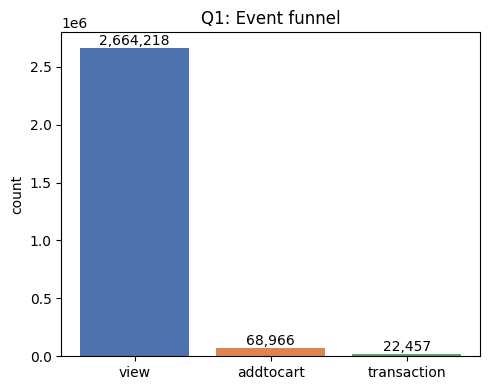

Q2. User activity (interactions per user): median = 1.0  mean = 1.52


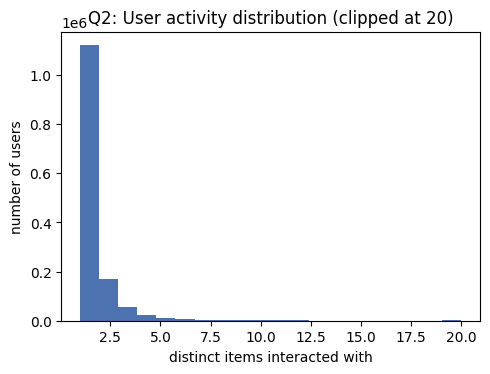

Q3. Top-1% items (2,350 items) account for 21.5% of all interactions


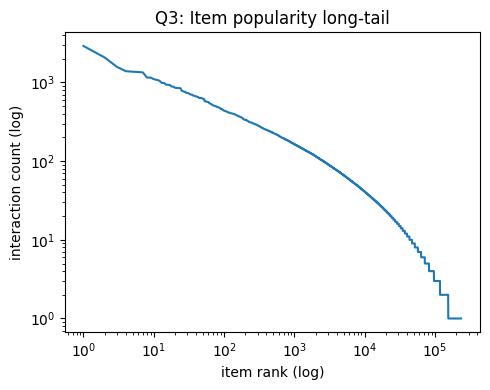


Q4. Sparsity: 0.999994 (2,145,179 observed / 330,867,162,380 possible)

Q5. Users with <3 interactions: 1,290,051 (91.7% of 1,407,580 users)
Q6. Items with <5 interactions: 153,156 (65.2% of 235,061 items)



Q7. Weekly events: 21 weeks, min=13,682, max=175,392


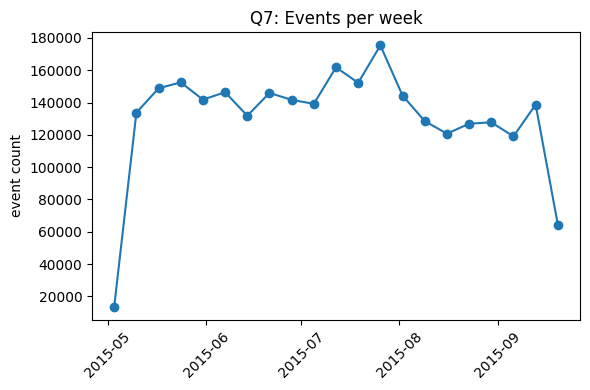

In [8]:
import matplotlib.pyplot as plt

# --- Q1: Event funnel ---
funnel = events["event"].value_counts().reindex(["view", "addtocart", "transaction"])
print("Q1. Event funnel:\n", funnel, "\n")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(funnel.index, funnel.values, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_title("Q1: Event funnel")
ax.set_ylabel("count")
for i, v in enumerate(funnel.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# --- Q2: User activity distribution ---
user_activity = interactions.groupby("visitorid").size()
print("Q2. User activity (interactions per user): median =", user_activity.median(),
      " mean = {:.2f}".format(user_activity.mean()))
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(user_activity.clip(upper=20), bins=20, color="#4c72b0")
ax.set_title("Q2: User activity distribution (clipped at 20)")
ax.set_xlabel("distinct items interacted with")
ax.set_ylabel("number of users")
plt.tight_layout()
plt.show()

# --- Q3: Item popularity long-tail ---
item_activity = interactions.groupby("itemid").size().sort_values(ascending=False)
top1pct_n = max(1, int(len(item_activity) * 0.01))
top1pct_share = item_activity.iloc[:top1pct_n].sum() / item_activity.sum()
print(f"Q3. Top-1% items ({top1pct_n:,} items) account for {top1pct_share:.1%} of all interactions")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(np.arange(1, len(item_activity) + 1), item_activity.values)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Q3: Item popularity long-tail")
ax.set_xlabel("item rank (log)")
ax.set_ylabel("interaction count (log)")
plt.tight_layout()
plt.show()

# --- Q4: Sparsity (computed in Cell 5) ---
print(f"\nQ4. Sparsity: {sparsity:.6f} ({n_pairs:,} observed / {n_users*n_items:,} possible)")

# --- Q5: Cold-start scope ---
cold_users = (user_activity < 3).sum()
print(f"\nQ5. Users with <3 interactions: {cold_users:,} ({cold_users/n_users:.1%} of {n_users:,} users)")

# --- Q6: Long-tail scope ---
longtail_items = (item_activity < 5).sum()
print(f"Q6. Items with <5 interactions: {longtail_items:,} ({longtail_items/n_items:.1%} of {n_items:,} items)")

# --- Q7: Temporal distribution ---
weekly = events.set_index("datetime").resample("W").size()
print(f"\nQ7. Weekly events: {len(weekly)} weeks, min={weekly.min():,}, max={weekly.max():,}")
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(weekly.index, weekly.values, marker="o")
ax.set_title("Q7: Events per week")
ax.set_ylabel("event count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cell 9: Save clean artifact
Save the cleaned, deduplicated, timestamped **event-level** log as `interactions.parquet` — this (not the Cell 5 visitor-item aggregate, which discards timestamps) is the input to Phase 2's temporal split, since splitting requires per-event dates.

In [9]:
clean_events = events[["visitorid", "itemid", "event", "event_weight", "timestamp", "datetime"]].copy()

out_path = PROCESSED_DIR / "interactions.parquet"
clean_events.to_parquet(out_path, index=False)

print("saved:", out_path.resolve())
print("final shape:", clean_events.shape)
print("\ndtypes:\n", clean_events.dtypes)
print("\nsample rows:\n", clean_events.sample(5, random_state=42))

saved: C:\Users\sriva\Downloads\retailrocket-recommender\data\processed\interactions.parquet
final shape: (2755641, 6)

dtypes:
 visitorid                int64
itemid                   int64
event                   object
event_weight             int64
timestamp                int64
datetime        datetime64[ns]
dtype: object

sample rows:
          visitorid  itemid      event  event_weight      timestamp  \
909614      711709  103121       view             1  1439872679911   
1483148     414122  274756  addtocart             2  1430780746545   
722936     1023164  208887       view             1  1438851299493   
917471      390114  339901       view             1  1439918360492   
2341314     951732   27767       view             1  1436803927746   

                       datetime  
909614  2015-08-18 04:37:59.911  
1483148 2015-05-04 23:05:46.545  
722936  2015-08-06 08:54:59.493  
917471  2015-08-18 17:19:20.492  
2341314 2015-07-13 16:12:07.746  
